In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("Base.csv")

print("Shape:", df.shape)

df.head()

Shape: (1000000, 32)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [3]:
print(df.isnull().sum())

fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                              0
session_leng

In [4]:
print(df["fraud_bool"].value_counts())

print(
    df["fraud_bool"].value_counts(normalize=True) * 100
)

fraud_bool
0    988971
1     11029
Name: count, dtype: int64
fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64


In [5]:
X = df.drop("fraud_bool", axis=1)

y = df["fraud_bool"]

In [6]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [7]:
X = X.sample(
    n=100000,
    random_state=42
)

y = y.loc[X.index]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [9]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())

print(y_train_smote.value_counts())

fraud_bool
0    79168
1      832
Name: count, dtype: int64
fraud_bool
0    79168
1    79168
Name: count, dtype: int64


In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
pred = rf.predict(X_test)

prob = rf.predict_proba(X_test)[:, 1]

In [12]:
print("Precision:",
      precision_score(y_test, pred))

print("Recall:",
      recall_score(y_test, pred))

print("ROC-AUC:",
      roc_auc_score(y_test, prob))

Precision: 0.08949416342412451
Recall: 0.11057692307692307
ROC-AUC: 0.8091124862026615


In [13]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19792
           1       0.09      0.11      0.10       208

    accuracy                           0.98     20000
   macro avg       0.54      0.55      0.54     20000
weighted avg       0.98      0.98      0.98     20000



In [14]:
print(
    confusion_matrix(
        y_test,
        pred
    )
)

[[19558   234]
 [  185    23]]


In [15]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                         Feature  Importance
45             device_os_windows    0.131239
22            keep_alive_session    0.105380
4                   customer_age    0.094667
15              phone_home_valid    0.080586
27               payment_type_AC    0.055061
18               has_other_cards    0.053849
3   current_address_months_count    0.050001
19         proposed_credit_limit    0.048402
0                         income    0.042355
17             bank_months_count    0.032335


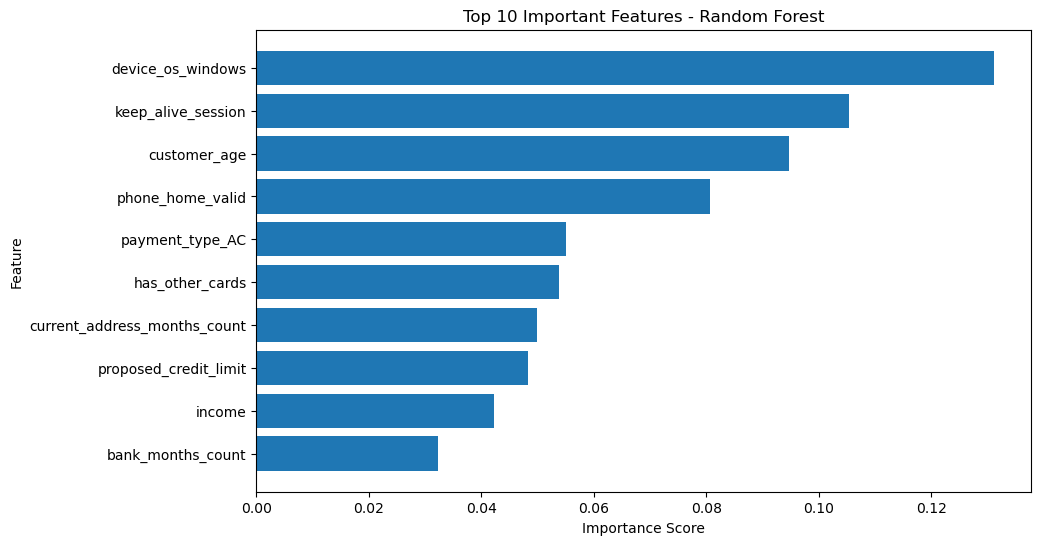

In [16]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()